<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-7-Three_Nonlinear_Hamiltonian%20Systems/Untitled189.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Quartic Oscillator**

We find the first energy $E_1$ given the boundary values $x_0$ and $x_1$.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch     0 | Loss = 3.19774687e-01 | E = 0.97906524 | F(E) = -5.56946158e-01
Epoch   500 | Loss = 6.45990018e-04 | E = 0.25404242 | F(E) = 7.83920288e-04
Epoch  1000 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  1500 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  2000 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  2500 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  3000 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  3500 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04
Epoch  4000 | Loss = 6.45990076e-04 | E = 0.25404236 | F(E) = 7.84158707e-04
Epoch  4500 | Loss = 6.45990018e-04 | E = 0.25404239 | F(E) = 7.84039497e-04

Approximation of the first energy:
E1 = 0.2540424


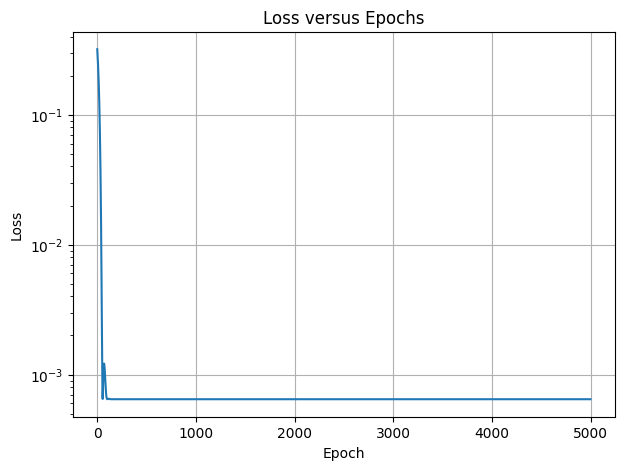

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# Boundary conditions
# ============================================================

x0 = 0.2
x1 = 0.8

# ============================================================
# Numerical quadrature points
# ============================================================

N_quad = 400

u_np = np.linspace(x0, x1, N_quad).astype(np.float32)
du = (x1 - x0)/(N_quad - 1)

u = tf.constant(u_np)

# ============================================================
# Neural network for E_theta(x0,x1)
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# ============================================================
# Input vector
# ============================================================

X_input = tf.constant([[x0, x1]], dtype=tf.float32)

# ============================================================
# Training
# ============================================================

epochs = 5000
loss_history = []

lambda_small = 0.01

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        # ----------------------------------------------------
        # Raw network output
        # ----------------------------------------------------

        raw_E = model(X_input)[0,0]

        # ----------------------------------------------------
        # Enforce positivity:
        # E > max(u^4)/2
        # ----------------------------------------------------

        Emin = tf.reduce_max(u**4)/2.0 + 1e-3

        E = Emin + tf.nn.softplus(raw_E)

        # ----------------------------------------------------
        # Compute integral
        # ----------------------------------------------------

        integrand = 1.0 / tf.sqrt(2.0*E - u**4)

        integral = tf.reduce_sum(integrand) * du

        # ----------------------------------------------------
        # Residual F(E)
        # ----------------------------------------------------

        F = integral - 1.0

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = F**2 + lambda_small * E**2

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.8e} | "
            f"E = {E.numpy():.8f} | "
            f"F(E) = {F.numpy():.8e}"
        )

# ============================================================
# Final energy
# ============================================================

raw_E = model(X_input)[0,0]
Emin = tf.reduce_max(u**4)/2.0 + 1e-3
E1 = Emin + tf.nn.softplus(raw_E)

print("\nApproximation of the first energy:")
print("E1 =", E1.numpy())

# ============================================================
# Plot loss
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss versus Epochs")
plt.grid(True)
plt.show()

**Finding the ground-state solution**

we consider a neural network with the boundary conditions hard embedded as
$$
x_{\theta}(t)
=
(1-t)x_0
+
tx_1
+
t(1-t)f_{\theta}(t),
$$
where $f_{\theta}(t)$ is a free neural network with a feed-forward architecture.

With the energy level \(E_1\) found before, we train the network by minimizing the loss
$$
\mathcal{L}(\theta)
=
\frac1N
\sum_{k=1}^N
\left(
\dot x_{\theta}(t_k)^2
+
x_{\theta}(t_k)^4
-
2E_1
\right)^2.
$$
This loss enforces conservation of energy along the trajectory. More precisely, it drives the neural network solution toward satisfying the identity
$$
\dot x(t)^2+x(t)^4=2E_1.$$


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch     0 | Loss = 2.88949627e-02
Epoch   500 | Loss = 1.92248190e-05
Epoch  1000 | Loss = 3.39485655e-06
Epoch  1500 | Loss = 3.12980092e-06


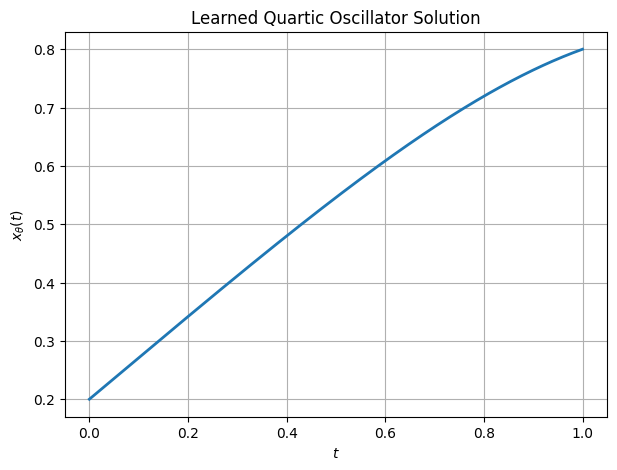

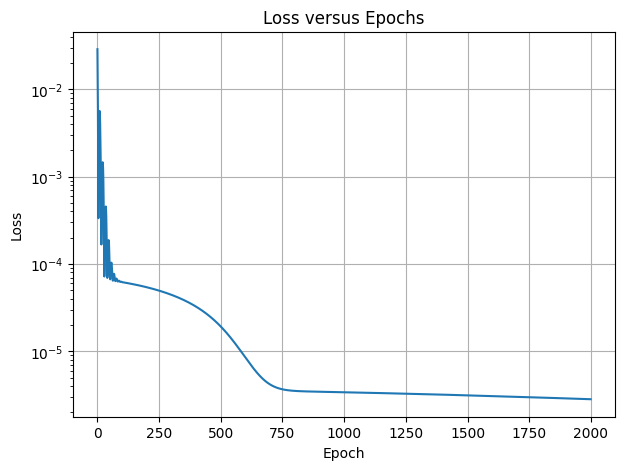

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

x0 = 0.2
x1 = 0.8
E1 = 0.25404


# ============================================================
# Training points
# ============================================================

N = 200

t_train = np.linspace(0.0, 1.0, N).reshape(-1,1).astype(np.float32)

t_tf = tf.constant(t_train)

# ============================================================
# Free neural network f_theta(t)
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

# ============================================================
# Hard embedding of boundary conditions
# ============================================================

def x_theta(t):

    f = model(t)

    return (
        (1.0 - t)*x0
        + t*x1
        + t*(1.0 - t)*f
    )

# ============================================================
# Training
# ============================================================

epochs = 2000

loss_history = []

for epoch in range(epochs):

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(t_tf)

        # ----------------------------------------------------
        # Solution
        # ----------------------------------------------------

        x = x_theta(t_tf)

        # ----------------------------------------------------
        # Derivative
        # ----------------------------------------------------

        x_t = tape.gradient(x, t_tf)

        # ----------------------------------------------------
        # Residual
        # ----------------------------------------------------

        residual = x_t**2 + x**4 - 2.0*E1

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = tf.reduce_mean(residual**2)

    grads = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.8e}"
        )

# ============================================================
# Compute final solution
# ============================================================

t_plot = np.linspace(0.0, 1.0, 400).reshape(-1,1).astype(np.float32)

x_plot = x_theta(tf.constant(t_plot)).numpy()

# ============================================================
# Plot solution
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(t_plot, x_plot, linewidth=2)

plt.xlabel(r"$t$")
plt.ylabel(r"$x_\theta(t)$")

plt.title("Learned Quartic Oscillator Solution")

plt.grid(True)

plt.show()

# ============================================================
# Plot loss
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss versus Epochs")

plt.grid(True)

plt.show()

**Learn simultaneously both the ground-state energy and the solution**


We consider a neural network with the boundary conditions hard embedded as before
$$
x_{\theta}(t)
=
(1-t)x_0
+
tx_1
+
t(1-t)f_{\theta}(t),
$$
where $f_{\theta}(t)$ is a free neural network.
To approximate the solution of Newton's equation
$$
\ddot x+2x^3=0,
$$
we minimize the ODE residual loss
$$
\mathcal{L}_{ODE}(\theta)
=
\frac1N
\sum_{k=1}^N
\left(
\ddot x_{\theta}(t_k)
+
2x_{\theta}(t_k)^3
\right)^2,
$$
with $\{t_k\}$ collocation points.

We also incorporate conservation of energy into the training process. We define the neural energy function
$$
E_{\theta}(t)
=
\frac12 \dot x_{\theta}(t)^2
+
\frac12 x_{\theta}(t)^4.
$$

We introduce the conservation loss
$$
\mathcal{L}_{cons}(\theta)
=
\frac1N
\sum_{k=1}^N
\left(
E_{\theta}(t_k)
-
\overline{E}_{\theta}
\right)^2,
$$
where
$$
\overline{E}_{\theta}
=
\frac1N
\sum_{k=1}^N
E_{\theta}(t_k)
$$
denotes the average energy over the collocation points.

The total loss is then taken as
$$
\mathcal{L}(\theta)
=
\mathcal{L}_{ODE}(\theta)
+
\lambda \mathcal{L}_{cons}(\theta),
$$
where $\lambda>0$  is a penalty parameter controlling the strength of the conservation law.

We introduce an additional regularization term in order to select the ground-state energy and its associated solution. To this end, we consider the penalty
$$
\mathcal{L}_{reg}(\theta)
=
(\overline{E}_{\theta})^2.
$$

 As a consequence, the neural network preferentially converges to the ground-state trajectory among all possible solutions satisfying the same boundary conditions.

The total loss is then defined as
$$
\mathcal{L}_{tot}(\theta)
=
\mathcal{L}_{ODE}(\theta)
+
\lambda \mathcal{L}_{cons}(\theta)
+
\mu \mathcal{L}_{reg}(\theta).
$$

Epoch     0 | Loss = 1.89475805e-01 | E_mean = 0.26571646
Epoch   500 | Loss = 6.41115708e-03 | E_mean = 0.25303486
Epoch  1000 | Loss = 6.41048700e-03 | E_mean = 0.25303590
Epoch  1500 | Loss = 6.40968652e-03 | E_mean = 0.25303620
Epoch  2000 | Loss = 6.40902761e-03 | E_mean = 0.25303632
Epoch  2500 | Loss = 6.40858384e-03 | E_mean = 0.25303638
Epoch  3000 | Loss = 6.40823366e-03 | E_mean = 0.25303647
Epoch  3500 | Loss = 6.40803622e-03 | E_mean = 0.25303718
Epoch  4000 | Loss = 6.40786299e-03 | E_mean = 0.25303653
Epoch  4500 | Loss = 6.40772562e-03 | E_mean = 0.25303644
Epoch  5000 | Loss = 6.40763761e-03 | E_mean = 0.25303578
Epoch  5500 | Loss = 6.64497958e-03 | E_mean = 0.25182801
Epoch  6000 | Loss = 6.40745647e-03 | E_mean = 0.25303662
Epoch  6500 | Loss = 6.41036686e-03 | E_mean = 0.25316280
Epoch  7000 | Loss = 6.40748953e-03 | E_mean = 0.25305417
Epoch  7500 | Loss = 6.67262357e-03 | E_mean = 0.25434950


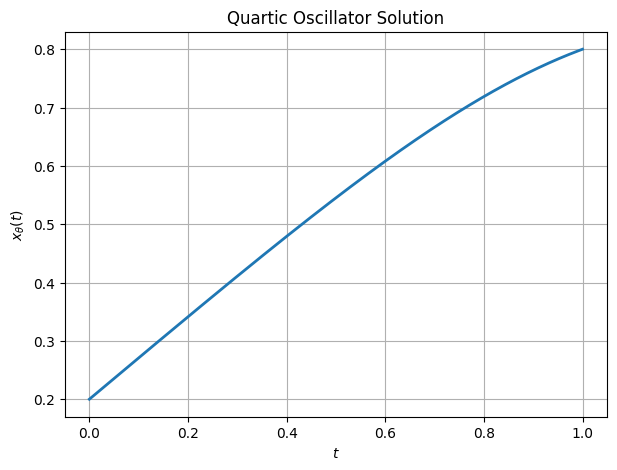

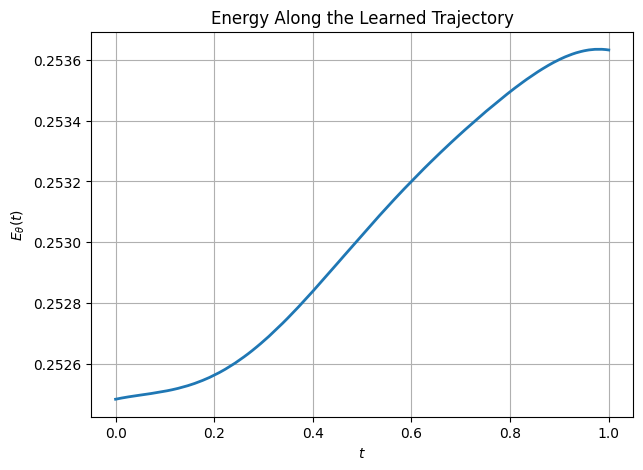

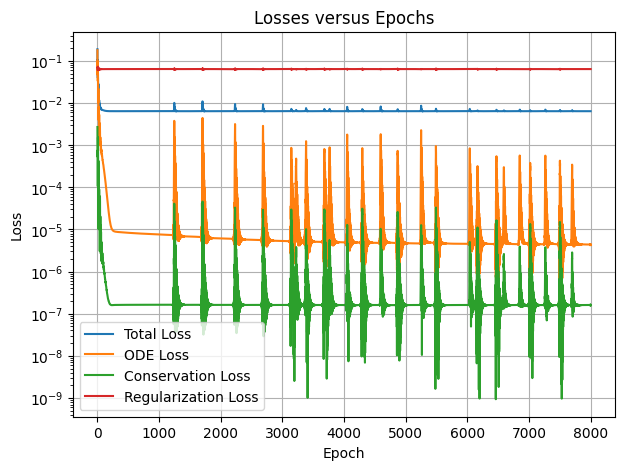

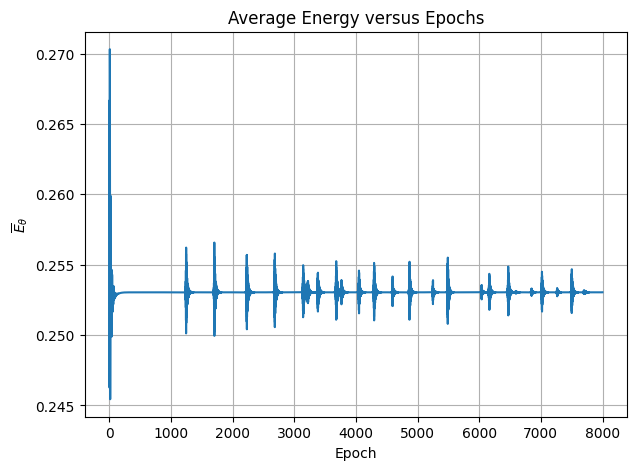


Final average energy:
0.25303948


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# Boundary conditions
# ============================================================

x0 = 0.2
x1 = 0.8

# ============================================================
# Training points
# ============================================================

N = 300

t_train = np.linspace(0.0, 1.0, N).reshape(-1,1).astype(np.float32)

t_tf = tf.constant(t_train)

# ============================================================
# Fourier feature layer
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def call(self, t):

        return tf.concat([
            t,
            tf.sin(t),
            tf.cos(t)
        ], axis=1)

# ============================================================
# Neural network
# ============================================================

inputs = tf.keras.Input(shape=(1,))

features = FourierLayer()(inputs)

x = tf.keras.layers.Dense(64, activation='tanh')(features)
x = tf.keras.layers.Dense(64, activation='tanh')(x)
x = tf.keras.layers.Dense(64, activation='tanh')(x)

outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# ============================================================
# Hard embedding
# ============================================================

def x_theta(t):

    f = model(t)

    return (
        (1.0 - t)*x0
        + t*x1
        + t*(1.0 - t)*f
    )

# ============================================================
# Penalty parameters
# ============================================================

lambda_cons = 1.0
mu_reg = 0.1

# ============================================================
# Training
# ============================================================

epochs = 8000

loss_history = []

loss_ode_history = []
loss_cons_history = []
loss_reg_history = []

energy_mean_history = []

for epoch in range(epochs):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(t_tf)

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch(t_tf)

            # ------------------------------------------------
            # Neural solution
            # ------------------------------------------------

            x = x_theta(t_tf)

        # ----------------------------------------------------
        # First derivative
        # ----------------------------------------------------

        x_t = tape1.gradient(x, t_tf)

        # ----------------------------------------------------
        # Second derivative
        # ----------------------------------------------------

        x_tt = tape2.gradient(x_t, t_tf)

        # ----------------------------------------------------
        # ODE residual
        # ----------------------------------------------------

        residual_ode = x_tt + 2.0*x**3

        loss_ode = tf.reduce_mean(residual_ode**2)

        # ----------------------------------------------------
        # Energy
        # ----------------------------------------------------

        E = 0.5*x_t**2 + 0.5*x**4

        E_mean = tf.reduce_mean(E)

        # ----------------------------------------------------
        # Conservation loss
        # ----------------------------------------------------

        loss_cons = tf.reduce_mean((E - E_mean)**2)

        # ----------------------------------------------------
        # Regularization loss
        # ----------------------------------------------------

        loss_reg = E_mean**2

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------

        loss = (
            loss_ode
            + lambda_cons*loss_cons
            + mu_reg*loss_reg
        )

    grads = tape2.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    loss_history.append(loss.numpy())

    loss_ode_history.append(loss_ode.numpy())
    loss_cons_history.append(loss_cons.numpy())
    loss_reg_history.append(loss_reg.numpy())

    energy_mean_history.append(E_mean.numpy())

    # --------------------------------------------------------
    # Print progress
    # --------------------------------------------------------

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.8e} | "
            f"E_mean = {E_mean.numpy():.8f}"
        )

# ============================================================
# Compute final solution
# ============================================================

t_plot = np.linspace(0.0, 1.0, 500).reshape(-1,1).astype(np.float32)

t_plot_tf = tf.constant(t_plot)

with tf.GradientTape(persistent=True) as tape2:

    tape2.watch(t_plot_tf)

    with tf.GradientTape() as tape1:

        tape1.watch(t_plot_tf)

        x_plot = x_theta(t_plot_tf)

    x_t_plot = tape1.gradient(x_plot, t_plot_tf)

x_tt_plot = tape2.gradient(x_t_plot, t_plot_tf)

# ============================================================
# Energy
# ============================================================

E_plot = 0.5*x_t_plot**2 + 0.5*x_plot**4

# ============================================================
# Convert to numpy
# ============================================================

x_plot = x_plot.numpy()
E_plot = E_plot.numpy()

# ============================================================
# Plot solution x(t)
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(t_plot, x_plot, linewidth=2)

plt.xlabel(r"$t$")
plt.ylabel(r"$x_\theta(t)$")

plt.title("Quartic Oscillator Solution")

plt.grid(True)

plt.show()

# ============================================================
# Plot energy
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(t_plot, E_plot, linewidth=2)

plt.xlabel(r"$t$")
plt.ylabel(r"$E_\theta(t)$")

plt.title("Energy Along the Learned Trajectory")

plt.grid(True)

plt.show()

# ============================================================
# Plot losses
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history, label='Total Loss')
plt.plot(loss_ode_history, label='ODE Loss')
plt.plot(loss_cons_history, label='Conservation Loss')
plt.plot(loss_reg_history, label='Regularization Loss')

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Losses versus Epochs")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# Plot average energy versus epochs
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(energy_mean_history)

plt.xlabel("Epoch")
plt.ylabel(r"$\overline{E}_\theta$")

plt.title("Average Energy versus Epochs")

plt.grid(True)

plt.show()

# ============================================================
# Final average energy
# ============================================================

print("\nFinal average energy:")
print(E_mean.numpy())

**Solving for an excited state**

We now seek a second trajectory satisfying the same boundary conditions as above, but corresponding to the next energy level, denoted by $E_2$.

To prevent the optimization from collapsing back to the ground-state energy $E_1$, we introduce the parametrization
$$
E_{\theta}
=
E_1+\mu e^{\phi},
$$
where $\phi$ is an trainable parameter and $\mu>0$ is an adjustable hyperparameter. Too small values of $\mu$ makes $E_2$ to collapse back into $E_1$. So we need to
adjust it until it converges to the next energy level.  We found that $\mu= 4.5$ is just the right value for the given boundary conditions.  
This  exponential construction automatically guarantees that
$$
E_{\theta}>E_1\approx 0.2530,
$$
thereby enforcing an ordering of the energy levels and preventing convergence toward the previously discovered solution.


Epoch     0 | Loss = 2.05061508e+02 | phi = -0.001000 | E2 = 4.75403976
Epoch   500 | Loss = 1.01537476e+01 | phi = 0.005576 | E2 = 4.77861118
Epoch  1000 | Loss = 9.31677628e+00 | phi = 0.104220 | E2 = 5.24695396
Epoch  1500 | Loss = 6.94098568e+00 | phi = 0.304222 | E2 = 6.35078716
Epoch  2000 | Loss = 1.92334950e+00 | phi = 0.632298 | E2 = 8.71709251
Epoch  2500 | Loss = 2.73399167e-02 | phi = 0.833409 | E2 = 10.60786438
Epoch  3000 | Loss = 6.34630793e-04 | phi = 0.854894 | E2 = 10.83397579
Epoch  3500 | Loss = 6.90274313e-02 | phi = 0.855377 | E2 = 10.84010696
Epoch  4000 | Loss = 2.83508474e-04 | phi = 0.855646 | E2 = 10.84205437
Epoch  4500 | Loss = 2.60284782e-04 | phi = 0.855580 | E2 = 10.84134960
Epoch  5000 | Loss = 1.01432972e-01 | phi = 0.855463 | E2 = 10.84185219
Epoch  5500 | Loss = 2.15904263e-04 | phi = 0.855692 | E2 = 10.84252739
Epoch  6000 | Loss = 1.82797026e-04 | phi = 0.855684 | E2 = 10.84245968
Epoch  6500 | Loss = 1.59784599e-04 | phi = 0.855675 | E2 = 10.84236

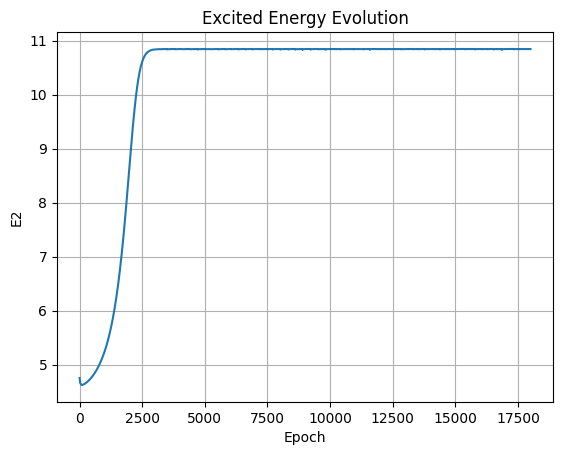

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# Boundary conditions
# ============================================================

x0 = 0.2
x1 = 0.8

# Ground-state energy
E1 = 0.25404

# ============================================================
# Training points
# ============================================================

N = 300

t_train = np.linspace(0,1,N).reshape(-1,1).astype(np.float32)

t_tf = tf.constant(t_train)

# ============================================================
# Fourier feature layer
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def call(self, t):

        return tf.concat([
            t,
            tf.sin(t),
            tf.cos(t)
        ], axis=1)

# ============================================================
# Neural network
# ============================================================

inputs = tf.keras.Input(shape=(1,))

features = FourierLayer()(inputs)

x = tf.keras.layers.Dense(64, activation='tanh')(features)
x = tf.keras.layers.Dense(64, activation='tanh')(x)
x = tf.keras.layers.Dense(64, activation='tanh')(x)

outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

# ============================================================
# Trainable excited-energy parameter
# ============================================================

phi = tf.Variable(0.0, trainable=True, dtype=tf.float32)

# ============================================================
# Optimizer
# ============================================================

optimizer = tf.keras.optimizers.Adam(0.001)

# ============================================================
# Hard embedding
# ============================================================

def x_theta(t):

    f = model(t)

    return (
        (1.0-t)*x0
        + t*x1
        + t*(1.0-t)*f
    )

# ============================================================
# Parameters
# ============================================================

lambda_energy = 10.0
mu = 0.01

epochs = 18000

# ============================================================
# History
# ============================================================

loss_history = []
E2_history = []

# ============================================================
# Training
# ============================================================

for epoch in range(epochs):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(t_tf)

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch(t_tf)

            x = x_theta(t_tf)

        # ----------------------------------------------------
        # Derivatives
        # ----------------------------------------------------

        x_t = tape1.gradient(x, t_tf)

        x_tt = tape2.gradient(x_t, t_tf)

        # ----------------------------------------------------
        # Excited energy
        # ----------------------------------------------------

        E2 = E1 + 4.5*tf.exp(phi)

        # ----------------------------------------------------
        # ODE residual
        # ----------------------------------------------------

        residual_ode = x_tt + 2.0*x**3

        loss_ode = tf.reduce_mean(residual_ode**2)

        # ----------------------------------------------------
        # Energy residual
        # ----------------------------------------------------

        energy = 0.5*x_t**2 + 0.5*x**4

        residual_energy = energy - E2

        loss_energy = tf.reduce_mean(residual_energy**2)

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------

        loss = (
            loss_ode
            + lambda_energy*loss_energy
            - 0*mu*phi
        )

    variables = model.trainable_variables + [phi]

    grads = tape2.gradient(loss, variables)

    optimizer.apply_gradients(zip(grads, variables))

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    loss_history.append(loss.numpy())

    E2_history.append(E2.numpy())

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.8e} | "
            f"phi = {phi.numpy():.6f} | "
            f"E2 = {E2.numpy():.8f}"
        )

# ============================================================
# Final energy
# ============================================================

print("\nFinal E2 =", E2.numpy())

# ============================================================
# Plot E2 evolution
# ============================================================

plt.plot(E2_history)

plt.xlabel("Epoch")
plt.ylabel("E2")

plt.title("Excited Energy Evolution")

plt.grid(True)

plt.show()

**Solving for an excited trajectory**

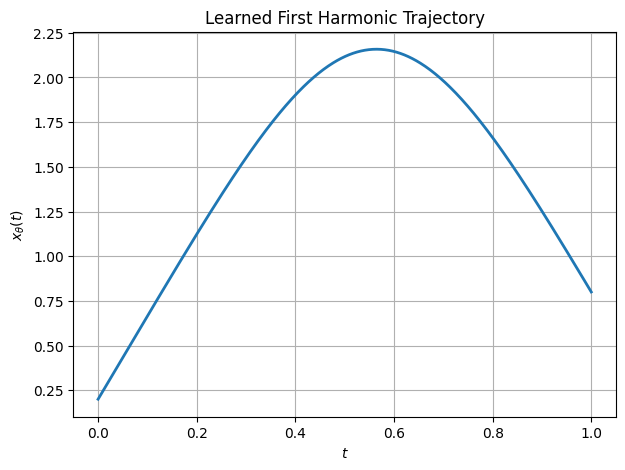

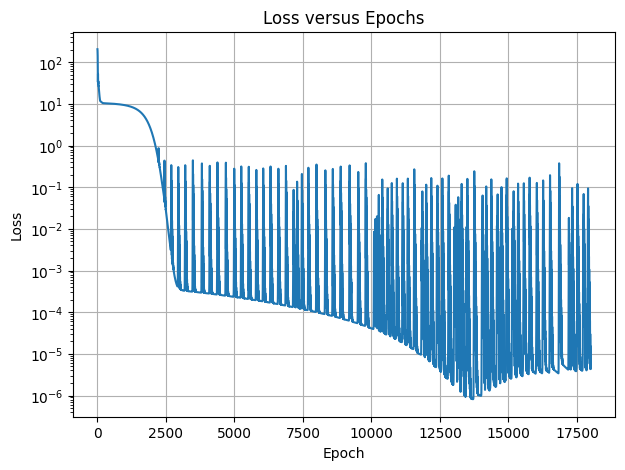

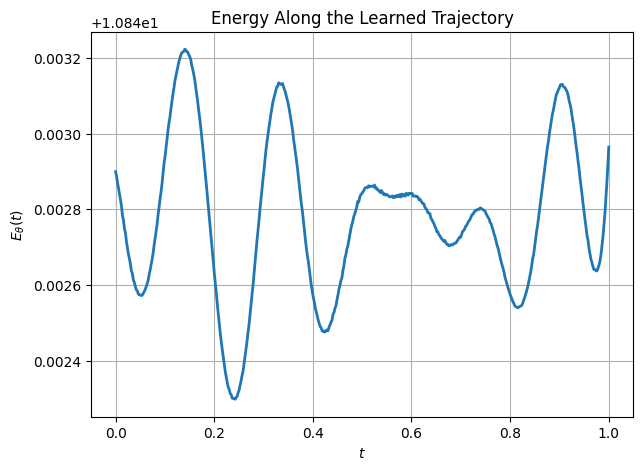

In [ ]:
# ============================================================
# Compute learned solution
# ============================================================

t_plot = np.linspace(0.0, 1.0, 500).reshape(-1,1).astype(np.float32)

t_plot_tf = tf.constant(t_plot)

with tf.GradientTape(persistent=True) as tape2:

    tape2.watch(t_plot_tf)

    with tf.GradientTape() as tape1:

        tape1.watch(t_plot_tf)

        x_plot = x_theta(t_plot_tf)

    # --------------------------------------------------------
    # First derivative
    # --------------------------------------------------------

    x_t_plot = tape1.gradient(x_plot, t_plot_tf)

# ============================================================
# Energy along trajectory
# ============================================================

energy_plot = (
    0.5*x_t_plot**2
    + 0.5*x_plot**4
)

# ============================================================
# Convert to numpy
# ============================================================

x_plot = x_plot.numpy()

energy_plot = energy_plot.numpy()

# ============================================================
# Plot solution x(t)
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(t_plot, x_plot, linewidth=2)

plt.xlabel(r"$t$")
plt.ylabel(r"$x_\theta(t)$")

plt.title("Learned First Harmonic Trajectory")

plt.grid(True)

plt.show()

# ============================================================
# Plot loss
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss versus Epochs")

plt.grid(True)

plt.show()

# ============================================================
# Plot energy along trajectory
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(t_plot, energy_plot, linewidth=2)

plt.xlabel(r"$t$")
plt.ylabel(r"$E_\theta(t)$")

plt.title("Energy Along the Learned Trajectory")

plt.grid(True)

plt.show()

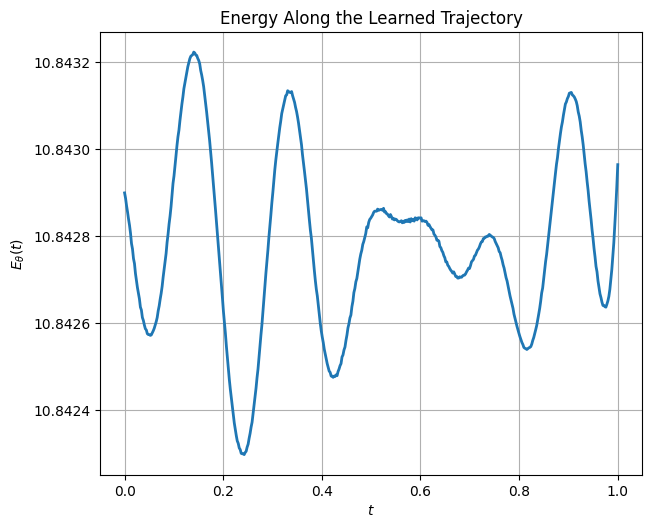

In [ ]:
plt.figure(figsize=(7,5.75))

plt.plot(t_plot, energy_plot, linewidth=2)

ax = plt.gca()

ax.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.xlabel(r"$t$")
plt.ylabel(r"$E_\theta(t)$")

plt.title("Energy Along the Learned Trajectory")

plt.grid(True)

plt.show()